# Experiment A — Documentation & Plot Generation
**Purpose:** Reproduce all publication-quality plots for the GitHub README and thesis Chapter 4.  
Run this notebook after `experiment_A_cnn_training.ipynb` has completed and saved all model files.

**Outputs saved to:** `Models/ExperimentA/doc_plots/`

## Section 1 — Mount Drive + Imports

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, classification_report
)
import tensorflow as tf
from tensorflow import keras

BASE         = '/content/drive/MyDrive/My Thesis'
PREPROCESSED = os.path.join(BASE, 'Preprocessed')
MODEL_DIR    = os.path.join(BASE, 'Models', 'ExperimentA')
PLOT_DIR     = os.path.join(MODEL_DIR, 'doc_plots')
os.makedirs(PLOT_DIR, exist_ok=True)

BATCH_SIZE  = 256
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ── Consistent plot style ──────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'      : 150,
    'font.family'     : 'DejaVu Sans',
    'font.size'       : 11,
    'axes.titlesize'  : 12,
    'axes.labelsize'  : 11,
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'axes.grid'       : True,
    'grid.alpha'      : 0.3,
    'lines.linewidth' : 2,
    'xtick.labelsize' : 10,
    'ytick.labelsize' : 10,
})

COLORS = {
    'dev01'   : '#2E86AB',   # steel blue
    'dev02'   : '#E84855',   # red
    'clean'   : '#2E86AB',
    'snr20'   : '#3BB273',
    'snr10'   : '#F4A261',
    'snr0'    : '#E84855',
    'single'  : '#E84855',
    'multi'   : '#F4A261',
    'augmented': '#3BB273',
}

print('Setup complete.')
print(f'Plots will be saved to: {PLOT_DIR}')

Mounted at /content/drive
Setup complete.
Plots will be saved to: /content/drive/MyDrive/My Thesis/Models/ExperimentA/doc_plots


## Section 2 — Load Results JSON and Models

In [2]:
# Load the results JSON saved by the training notebook
with open(os.path.join(MODEL_DIR, 'experiment_A_results.json')) as f:
    results_A = json.load(f)

print('Results loaded:')
print(f'  Modulation   : {results_A["modulation"]}')
print(f'  Total params : {results_A["total_params"]:,}')
print(f'  Best epoch   : {results_A["best_epoch"]}')
print(f'  Val accuracy : {results_A["val_accuracy"]*100:.2f}%')

# Load all three models
model_single = keras.models.load_model(os.path.join(MODEL_DIR, 'best_model.keras'))
model_multi  = keras.models.load_model(os.path.join(MODEL_DIR, 'best_model_multisession.keras'))
model_aug    = keras.models.load_model(os.path.join(MODEL_DIR, 'best_model_augmented.keras'))
print('\nAll three models loaded.')

Results loaded:
  Modulation   : BPSK
  Total params : 43,874
  Best epoch   : 99
  Val accuracy : 100.00%

All three models loaded.


## Section 3 — Plot 1: CNN Architecture Diagram

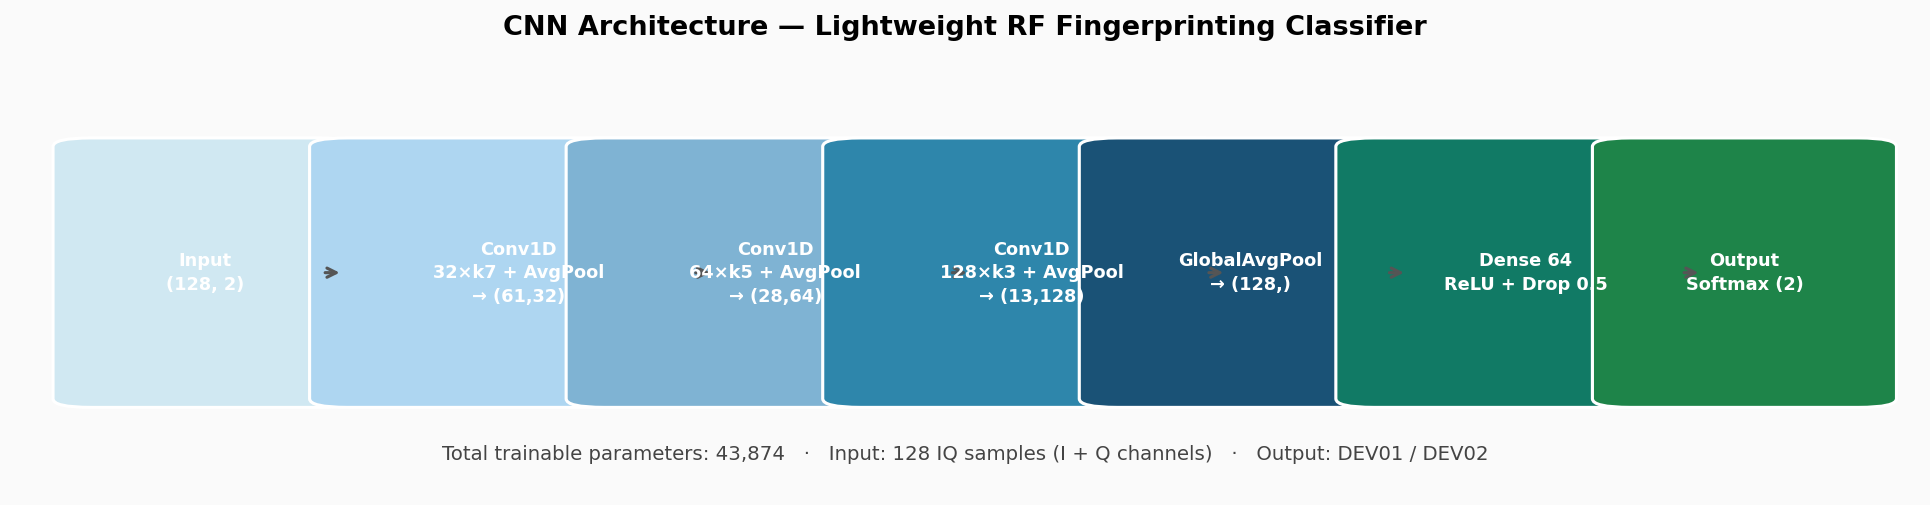

Saved: /content/drive/MyDrive/My Thesis/Models/ExperimentA/doc_plots/P01_cnn_architecture.png


In [3]:
fig, ax = plt.subplots(figsize=(13, 3.5))
ax.axis('off')
fig.patch.set_facecolor('#FAFAFA')

layers_info = [
    ('Input\n(128, 2)',        '#D0E8F2', 1.2),
    ('Conv1D\n32×k7 + AvgPool\n→ (61,32)',  '#AED6F1', 1.8),
    ('Conv1D\n64×k5 + AvgPool\n→ (28,64)',  '#7FB3D3', 1.8),
    ('Conv1D\n128×k3 + AvgPool\n→ (13,128)', '#2E86AB', 1.8),
    ('GlobalAvgPool\n→ (128,)',  '#1A5276', 1.4),
    ('Dense 64\nReLU + Drop 0.5', '#117A65', 1.6),
    ('Output\nSoftmax (2)',    '#1E8449', 1.2),
]

x_pos   = 0.04
spacing = 0.135
box_h   = 0.58

for i, (label, color, width) in enumerate(layers_info):
    x = x_pos + i * spacing
    rect = mpatches.FancyBboxPatch(
        (x, 0.21), width * 0.10, box_h,
        boxstyle='round,pad=0.02',
        facecolor=color, edgecolor='white', linewidth=1.5,
        transform=ax.transAxes
    )
    ax.add_patch(rect)
    ax.text(x + width * 0.05, 0.50, label,
            transform=ax.transAxes, ha='center', va='center',
            fontsize=8.5, color='white', fontweight='bold',
            linespacing=1.4)
    # Arrow
    if i < len(layers_info) - 1:
        ax.annotate('', xy=(x + width * 0.10 + 0.013, 0.50),
                    xytext=(x + width * 0.10 + 0.001, 0.50),
                    xycoords='axes fraction',
                    arrowprops=dict(arrowstyle='->', color='#555', lw=1.5))

ax.text(0.50, 0.06,
        f'Total trainable parameters: {results_A["total_params"]:,}   ·   '
        f'Input: 128 IQ samples (I + Q channels)   ·   Output: DEV01 / DEV02',
        transform=ax.transAxes, ha='center', va='bottom',
        fontsize=9.5, color='#444')

ax.set_title('CNN Architecture — Lightweight RF Fingerprinting Classifier',
             fontsize=13, fontweight='bold', pad=10)

plt.tight_layout()
p = os.path.join(PLOT_DIR, 'P01_cnn_architecture.png')
plt.savefig(p, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'Saved: {p}')

## Section 4 — Plot 2: Three-Model Progression (SNR sweep comparison)

In [4]:
# Pre-computed results from training notebook
snr_order  = [0, 10, 20, None]
snr_labels = ['SNR 0 dB', 'SNR 10 dB', 'SNR 20 dB', 'Clean\n(∞ dB)']

# Single-session model results (from training notebook output)
single_acc  = [83.55, 94.35, 99.52, 100.00]

# Multi-session model (cross-session collapsed, so we only have S2 clean=100)
# Run a quick SNR sweep on S2 for completeness
print('Running SNR sweep for multi-session model on S2...')
multi_acc = []
aug_acc   = []

for snr in snr_order:
    tag   = 'clean' if snr is None else f'SNR{snr}'
    X_s2  = np.load(os.path.join(PREPROCESSED, 'S2', f'BPSK_{tag}_X.npy'))
    y_s2  = np.load(os.path.join(PREPROCESSED, 'S2', f'BPSK_{tag}_y.npy'))

    _, acc_m = model_multi.evaluate(X_s2, y_s2, batch_size=BATCH_SIZE, verbose=0)
    _, acc_a = model_aug.evaluate(X_s2,   y_s2, batch_size=BATCH_SIZE, verbose=0)
    multi_acc.append(round(acc_m * 100, 2))
    aug_acc.append(round(acc_a * 100, 2))

    label = 'clean' if snr is None else f'SNR{snr}'
    print(f'  {label:<8}  multi={acc_m*100:.2f}%  aug={acc_a*100:.2f}%')
    del X_s2, y_s2

print('Done.')

Running SNR sweep for multi-session model on S2...
  SNR0      multi=57.26%  aug=99.98%
  SNR10     multi=99.51%  aug=100.00%
  SNR20     multi=100.00%  aug=100.00%
  clean     multi=100.00%  aug=100.00%
Done.


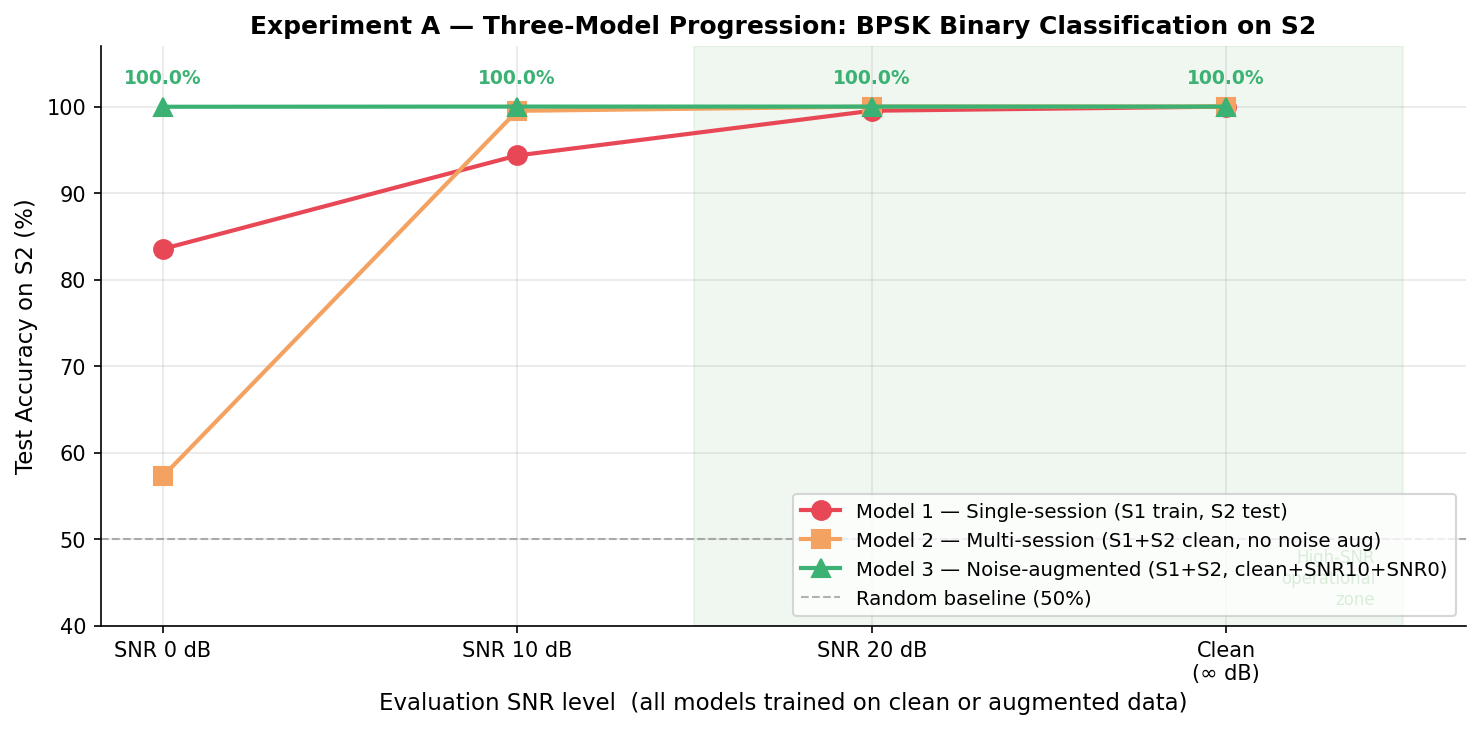

Saved: /content/drive/MyDrive/My Thesis/Models/ExperimentA/doc_plots/P02_three_model_snr_progression.png


In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

xs = range(4)
ax.plot(xs, single_acc, marker='o', color=COLORS['single'],  linewidth=2,
        markersize=9, label='Model 1 — Single-session (S1 train, S2 test)')
ax.plot(xs, multi_acc,  marker='s', color=COLORS['multi'],   linewidth=2,
        markersize=9, label='Model 2 — Multi-session (S1+S2 clean, no noise aug)')
ax.plot(xs, aug_acc,    marker='^', color=COLORS['augmented'],linewidth=2,
        markersize=9, label='Model 3 — Noise-augmented (S1+S2, clean+SNR10+SNR0)')

# Annotate aug_acc
for i, v in enumerate(aug_acc):
    ax.annotate(f'{v:.1f}%', (i, v),
                textcoords='offset points', xytext=(0, 11),
                ha='center', fontsize=9, color=COLORS['augmented'], fontweight='bold')

ax.axhline(50, linestyle='--', color='grey', linewidth=1, alpha=0.6, label='Random baseline (50%)')
ax.set_xticks(xs)
ax.set_xticklabels(snr_labels)
ax.set_ylabel('Test Accuracy on S2 (%)')
ax.set_xlabel('Evaluation SNR level  (all models trained on clean or augmented data)')
ax.set_title('Experiment A — Three-Model Progression: BPSK Binary Classification on S2',
             fontweight='bold')
ax.set_ylim([40, 107])
ax.legend(fontsize=9.5, loc='lower right')

# Shade the "operational zone"
ax.axvspan(1.5, 3.5, alpha=0.06, color='green', label='_')
ax.text(3.42, 42, 'High-SNR\noperational\nzone', fontsize=8, color='green',
        ha='right', va='bottom', alpha=0.7)

plt.tight_layout()
p = os.path.join(PLOT_DIR, 'P02_three_model_snr_progression.png')
plt.savefig(p, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')

## Section 5 — Plot 3: Cross-Session Failure and Fix

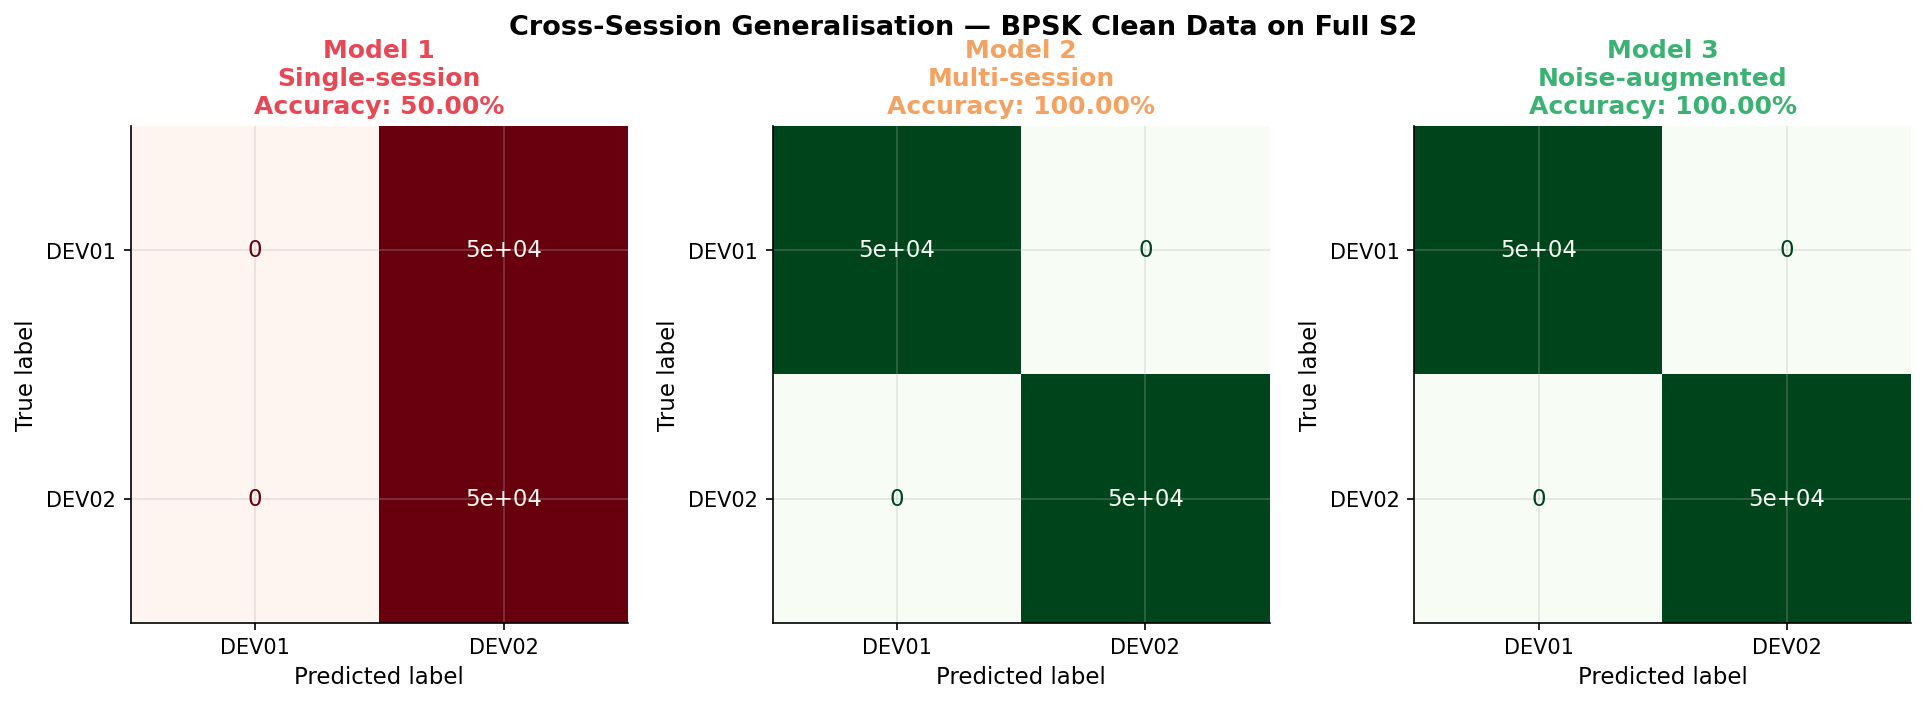

Saved: /content/drive/MyDrive/My Thesis/Models/ExperimentA/doc_plots/P03_cross_session_confusion.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
fig.suptitle('Cross-Session Generalisation — BPSK Clean Data on Full S2',
             fontsize=13, fontweight='bold')

model_configs = [
    (model_single, 'Model 1\nSingle-session',  COLORS['single']),
    (model_multi,  'Model 2\nMulti-session',   COLORS['multi']),
    (model_aug,    'Model 3\nNoise-augmented', COLORS['augmented']),
]

X_s2c = np.load(os.path.join(PREPROCESSED, 'S2', 'BPSK_clean_X.npy'))
y_s2c = np.load(os.path.join(PREPROCESSED, 'S2', 'BPSK_clean_y.npy'))

for ax, (mdl, title, color) in zip(axes, model_configs):
    _, acc = mdl.evaluate(X_s2c, y_s2c, batch_size=BATCH_SIZE, verbose=0)
    prob   = mdl.predict(X_s2c, batch_size=BATCH_SIZE, verbose=0)
    pred   = np.argmax(prob, axis=1)
    cm_    = confusion_matrix(y_s2c, pred)

    disp = ConfusionMatrixDisplay(cm_, display_labels=['DEV01', 'DEV02'])
    disp.plot(ax=ax, colorbar=False,
              cmap='Greens' if acc > 0.9 else 'Reds')
    ax.set_title(f'{title}\nAccuracy: {acc*100:.2f}%',
                 color=color, fontweight='bold')

del X_s2c, y_s2c

plt.tight_layout()
p = os.path.join(PLOT_DIR, 'P03_cross_session_confusion.png')
plt.savefig(p, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')

## Section 6 — Plot 4: SNR Robustness — Final Augmented Model (Accuracy + AUC)

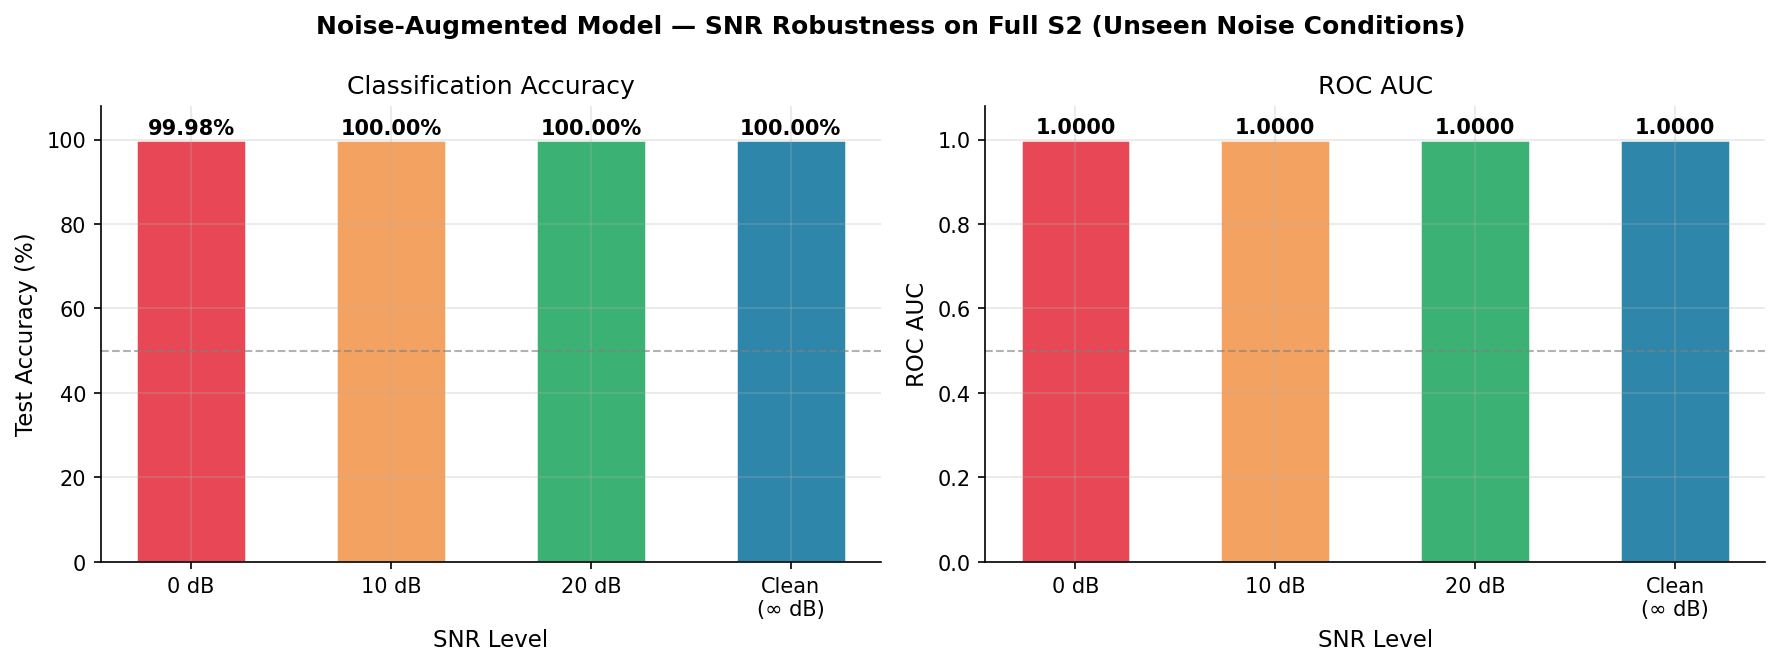

Saved: /content/drive/MyDrive/My Thesis/Models/ExperimentA/doc_plots/P04_augmented_snr_robustness.png


In [7]:
snr_plot_order  = [0, 10, 20, None]
snr_plot_labels = ['0 dB', '10 dB', '20 dB', 'Clean\n(∞ dB)']
aug_accs, aug_aucs = [], []

for snr in snr_plot_order:
    tag  = 'clean' if snr is None else f'SNR{snr}'
    Xs2  = np.load(os.path.join(PREPROCESSED, 'S2', f'BPSK_{tag}_X.npy'))
    ys2  = np.load(os.path.join(PREPROCESSED, 'S2', f'BPSK_{tag}_y.npy'))
    _, acc_ = model_aug.evaluate(Xs2, ys2, batch_size=BATCH_SIZE, verbose=0)
    prob_   = model_aug.predict(Xs2, batch_size=BATCH_SIZE, verbose=0)
    fpr_, tpr_, _ = roc_curve(ys2, prob_[:, 1])
    auc_ = auc(fpr_, tpr_)
    aug_accs.append(acc_ * 100)
    aug_aucs.append(auc_)
    del Xs2, ys2, prob_

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle('Noise-Augmented Model — SNR Robustness on Full S2 (Unseen Noise Conditions)',
             fontsize=12, fontweight='bold')

bar_colors = [COLORS['snr0'], COLORS['snr10'], COLORS['snr20'], COLORS['clean']]

# Accuracy bar chart
bars = ax1.bar(snr_plot_labels, aug_accs, color=bar_colors,
               edgecolor='white', linewidth=1.2, width=0.55)
for bar, val in zip(bars, aug_accs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.axhline(50, linestyle='--', color='grey', linewidth=1, alpha=0.6)
ax1.set_ylabel('Test Accuracy (%)')
ax1.set_xlabel('SNR Level')
ax1.set_title('Classification Accuracy')
ax1.set_ylim([0, 108])

# AUC bar chart
bars2 = ax2.bar(snr_plot_labels, aug_aucs, color=bar_colors,
                edgecolor='white', linewidth=1.2, width=0.55)
for bar, val in zip(bars2, aug_aucs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.axhline(0.5, linestyle='--', color='grey', linewidth=1, alpha=0.6)
ax2.set_ylabel('ROC AUC')
ax2.set_xlabel('SNR Level')
ax2.set_title('ROC AUC')
ax2.set_ylim([0, 1.08])

plt.tight_layout()
p = os.path.join(PLOT_DIR, 'P04_augmented_snr_robustness.png')
plt.savefig(p, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')

## Section 7 — Plot 5: Confidence Analysis (Silent Failure at SNR 0 dB)

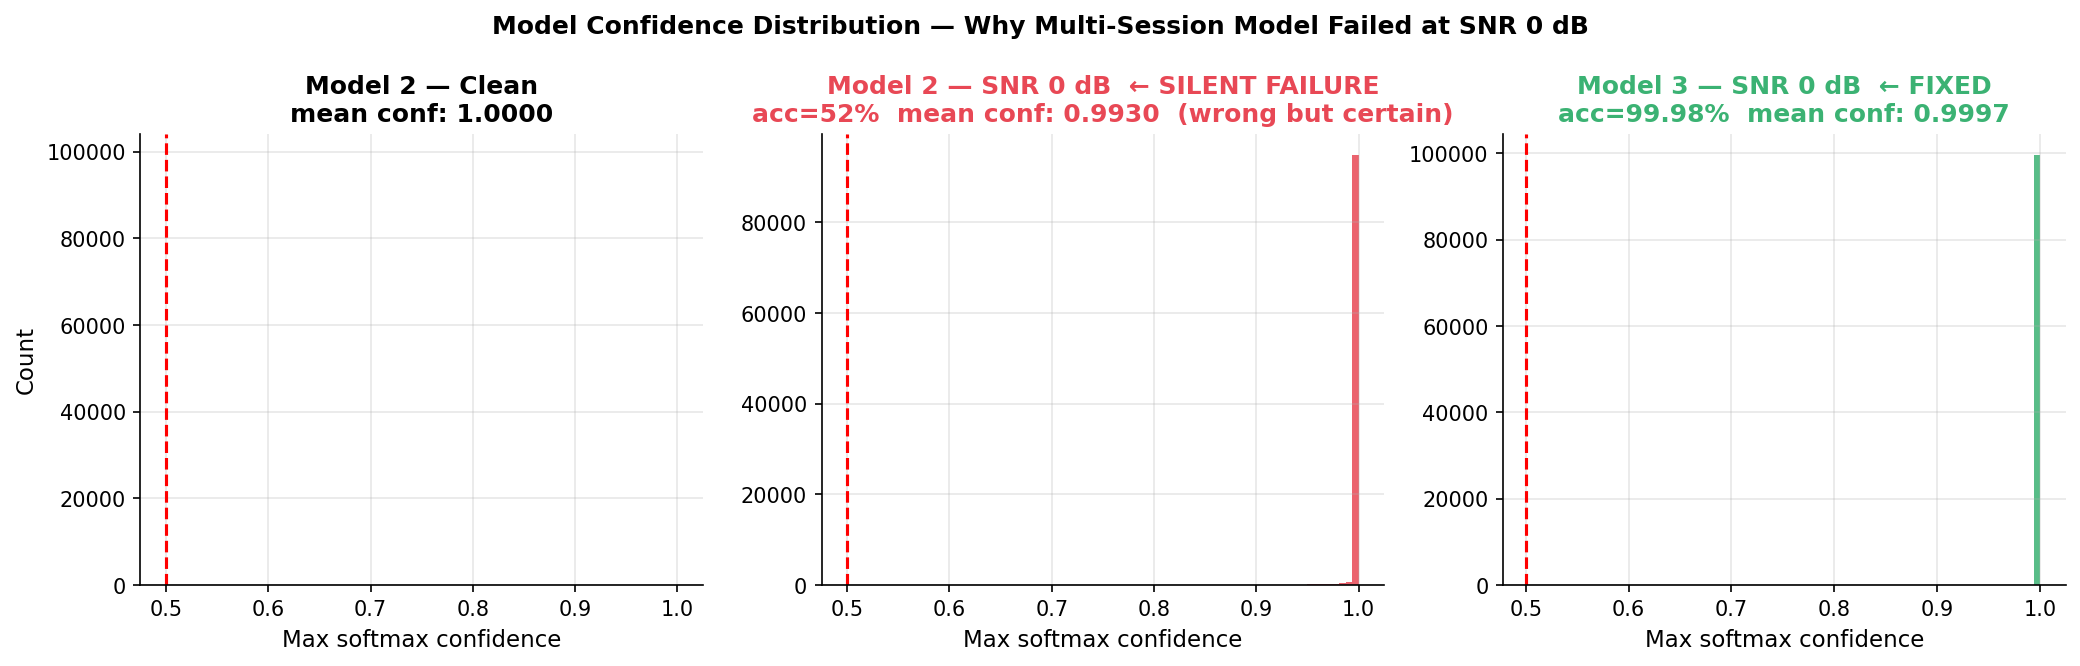

Saved: /content/drive/MyDrive/My Thesis/Models/ExperimentA/doc_plots/P05_confidence_silent_failure.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.suptitle(
    'Model Confidence Distribution — Why Multi-Session Model Failed at SNR 0 dB',
    fontsize=12, fontweight='bold'
)

# Load SNR 0 and clean S2
X_snr0 = np.load(os.path.join(PREPROCESSED, 'S2', 'BPSK_SNR0_X.npy'))
y_snr0 = np.load(os.path.join(PREPROCESSED, 'S2', 'BPSK_SNR0_y.npy'))
X_cln  = np.load(os.path.join(PREPROCESSED, 'S2', 'BPSK_clean_X.npy'))

prob_multi_snr0 = model_multi.predict(X_snr0, batch_size=BATCH_SIZE, verbose=0)
prob_multi_cln  = model_multi.predict(X_cln,  batch_size=BATCH_SIZE, verbose=0)
prob_aug_snr0   = model_aug.predict(X_snr0,   batch_size=BATCH_SIZE, verbose=0)

conf_multi_cln  = np.max(prob_multi_cln,  axis=1)
conf_multi_snr0 = np.max(prob_multi_snr0, axis=1)
conf_aug_snr0   = np.max(prob_aug_snr0,   axis=1)

# Panel 1: Multi-session model, clean
axes[0].hist(conf_multi_cln, bins=80, color=COLORS['clean'], alpha=0.85, edgecolor='none')
axes[0].axvline(0.5, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title(f'Model 2 — Clean\nmean conf: {conf_multi_cln.mean():.4f}', fontweight='bold')
axes[0].set_xlabel('Max softmax confidence')
axes[0].set_ylabel('Count')

# Panel 2: Multi-session model, SNR 0 — the silent failure
axes[1].hist(conf_multi_snr0, bins=80, color=COLORS['single'], alpha=0.85, edgecolor='none')
axes[1].axvline(0.5, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title(
    f'Model 2 — SNR 0 dB  ← SILENT FAILURE\n'
    f'acc=52%  mean conf: {conf_multi_snr0.mean():.4f}  (wrong but certain)',
    fontweight='bold', color=COLORS['single']
)
axes[1].set_xlabel('Max softmax confidence')

# Panel 3: Augmented model, SNR 0 — fixed
axes[2].hist(conf_aug_snr0, bins=80, color=COLORS['augmented'], alpha=0.85, edgecolor='none')
axes[2].axvline(0.5, color='red', linestyle='--', linewidth=1.5)
axes[2].set_title(
    f'Model 3 — SNR 0 dB  ← FIXED\n'
    f'acc=99.98%  mean conf: {conf_aug_snr0.mean():.4f}',
    fontweight='bold', color=COLORS['augmented']
)
axes[2].set_xlabel('Max softmax confidence')

del X_snr0, y_snr0, X_cln

plt.tight_layout()
p = os.path.join(PLOT_DIR, 'P05_confidence_silent_failure.png')
plt.savefig(p, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')

## Section 8 — Plot 6: Final Model ROC Curves at Each SNR

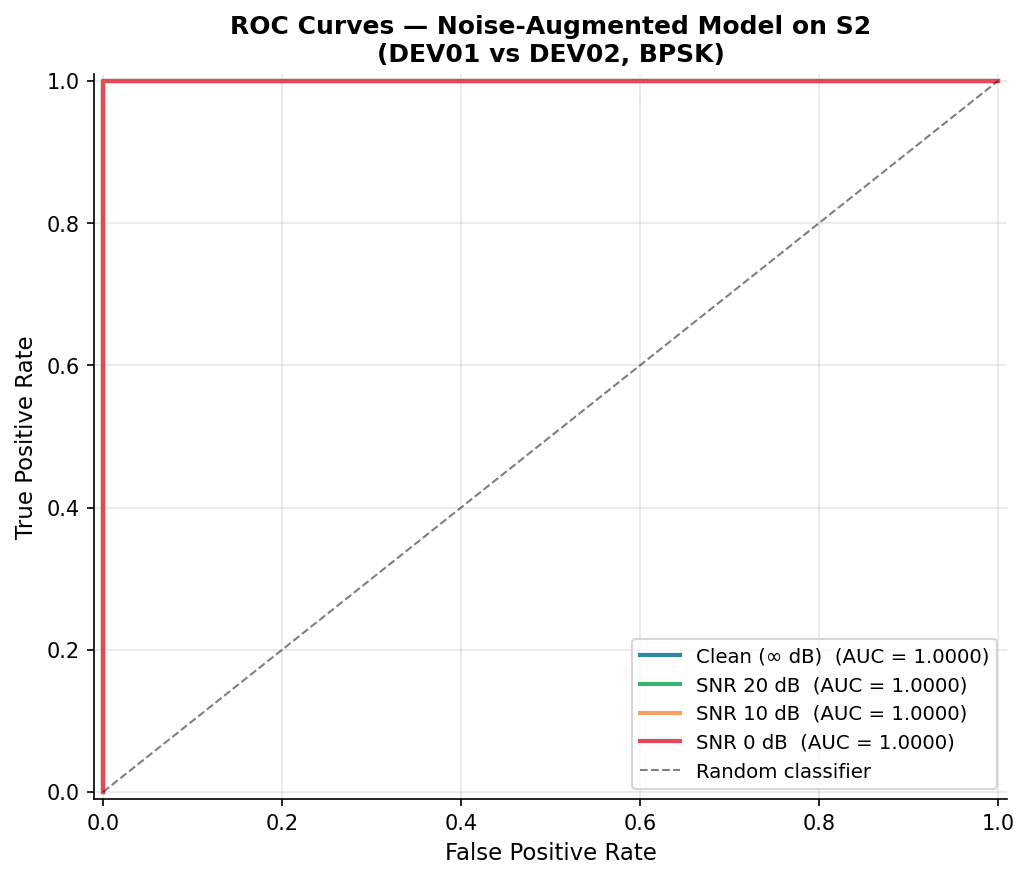

Saved: /content/drive/MyDrive/My Thesis/Models/ExperimentA/doc_plots/P06_roc_curves_snr.png


In [9]:
fig, ax = plt.subplots(figsize=(7, 6))

snr_roc = [(None, 'Clean (∞ dB)', COLORS['clean']),
           (20,   'SNR 20 dB',    COLORS['snr20']),
           (10,   'SNR 10 dB',    COLORS['snr10']),
           (0,    'SNR 0 dB',     COLORS['snr0'])]

for snr, label, color in snr_roc:
    tag  = 'clean' if snr is None else f'SNR{snr}'
    Xs2  = np.load(os.path.join(PREPROCESSED, 'S2', f'BPSK_{tag}_X.npy'))
    ys2  = np.load(os.path.join(PREPROCESSED, 'S2', f'BPSK_{tag}_y.npy'))
    prob = model_aug.predict(Xs2, batch_size=BATCH_SIZE, verbose=0)
    fpr_, tpr_, _ = roc_curve(ys2, prob[:, 1])
    auc_ = auc(fpr_, tpr_)
    ax.plot(fpr_, tpr_, color=color, linewidth=2,
            label=f'{label}  (AUC = {auc_:.4f})')
    del Xs2, ys2, prob

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Noise-Augmented Model on S2\n(DEV01 vs DEV02, BPSK)',
             fontweight='bold')
ax.legend(fontsize=9.5, loc='lower right')
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])

plt.tight_layout()
p = os.path.join(PLOT_DIR, 'P06_roc_curves_snr.png')
plt.savefig(p, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')

## Section 9 — Plot 7: Final Summary Table (Results Card)

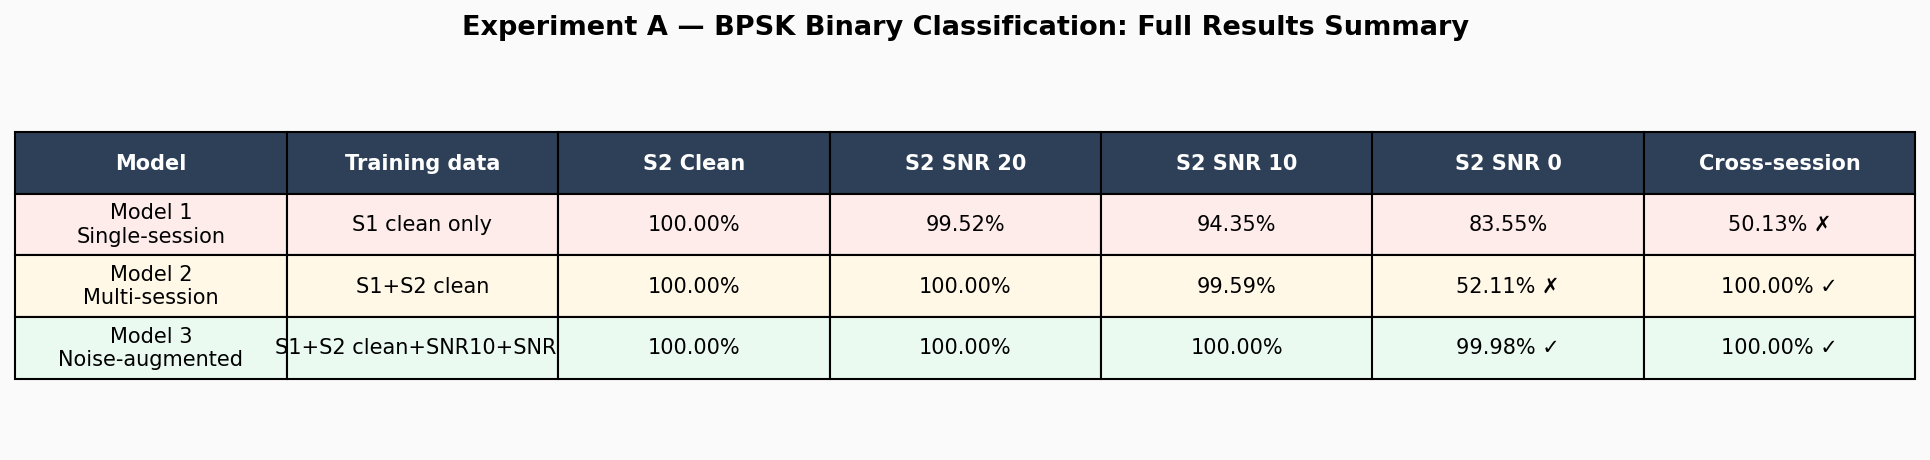

Saved: /content/drive/MyDrive/My Thesis/Models/ExperimentA/doc_plots/P07_results_summary_table.png


In [10]:
fig, ax = plt.subplots(figsize=(13, 3.2))
ax.axis('off')
fig.patch.set_facecolor('#FAFAFA')

col_labels = ['Model', 'Training data',
              'S2 Clean', 'S2 SNR 20', 'S2 SNR 10', 'S2 SNR 0', 'Cross-session']

table_data = [
    ['Model 1\nSingle-session', 'S1 clean only',
     '100.00%', '99.52%', '94.35%', '83.55%', '50.13% ✗'],
    ['Model 2\nMulti-session', 'S1+S2 clean',
     '100.00%', '100.00%', '99.59%', '52.11% ✗', '100.00% ✓'],
    ['Model 3\nNoise-augmented', 'S1+S2 clean+SNR10+SNR0',
     '100.00%', '100.00%', '100.00%', '99.98% ✓', '100.00% ✓'],
]

row_colors_list = [
    ['#FDECEA'] * 7,
    ['#FFF8E7'] * 7,
    ['#EAFAF1'] * 7,
]

tbl = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
    cellColours=row_colors_list,
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 2.4)

for j in range(len(col_labels)):
    tbl[0, j].set_facecolor('#2E4057')
    tbl[0, j].set_text_props(color='white', fontweight='bold')

ax.set_title('Experiment A — BPSK Binary Classification: Full Results Summary',
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
p = os.path.join(PLOT_DIR, 'P07_results_summary_table.png')
plt.savefig(p, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'Saved: {p}')

## Section 10 — Generate README.md

In [11]:
readme = '''# Experiment A — BPSK Binary Device Classification

**Thesis:** Lightweight Device Authentication in Wireless Communication Using RF Fingerprinting
**Authors:** Amitha · Tharangi Madushani
**Supervisor:** Prof. Qinghua Wang · **Examiner:** Ali
**University:** Kristianstad University (HKR) · DT339G VT26

---

## Overview

Experiment A trains and evaluates a lightweight 1D CNN to classify radio transmissions from two physically distinct CC1101+ESP32 devices using raw IQ samples — no manual feature engineering. The modulation used is BPSK. This experiment answers three questions:

1. Can a CNN learn device-intrinsic RF fingerprints from raw IQ data?
2. Does the fingerprint survive across recording sessions (different days)?
3. Does the fingerprint survive under additive channel noise?

---

## Hardware Setup

| Role | Device | Serial |
|---|---|---|
| Transmitter 1 | DEV01 (label 0) | 3288FF2 |
| Transmitter 2 | DEV02 (label 1) | 3467EEC |
| Receiver | RTL-SDR V3 | 3288FAD |

**Fixed recording parameters:** Centre freq 900 MHz · Sample rate 1 MHz · TX gain 30 · RX gain 30 · AGC OFF · FE corrections OFF

---

## CNN Architecture

![Architecture](doc_plots/P01_cnn_architecture.png)

| Layer | Configuration | Output shape |
|---|---|---|
| Input | 128 IQ samples, I and Q channels | (128, 2) |
| Conv1D + AvgPool | 32 filters, kernel=7, valid | (61, 32) |
| Conv1D + AvgPool | 64 filters, kernel=5, valid | (28, 64) |
| Conv1D + AvgPool | 128 filters, kernel=3, valid | (13, 128) |
| GlobalAvgPool1D | — | (128,) |
| Dense + Dropout 0.5 | 64 units, ReLU | (64,) |
| Output | 2 units, Softmax | (2,) |
| **Total params** | | **43,874** |

**Key design decisions:**
- AveragePooling not MaxPooling — preserves amplitude envelope information
- GlobalAveragePooling1D not Flatten — better generalisation across window positions
- No mean subtraction in preprocessing — preserves DC offset which encodes CFO
- Normalised by max absolute amplitude only — removes session-dependent power variation

---

## Preprocessing Pipeline

For each `.dat` recording:

1. Drop first 100,000 samples (power-on transient)
2. Normalise by max absolute amplitude — **no mean subtraction**
3. Subsample 10,000 windows per file (RAM constraint)
4. Segment into non-overlapping 128-sample windows → shape `(N, 128, 2)`
5. Label: DEV01 = 0, DEV02 = 1
6. Inject AWGN offline at SNR = ∞ (clean), 20, 10, 0 dB

**Per modulation per SNR:** 100,000 windows total (50,000 per device × 2 devices)

---

## Three-Model Progression

Three models were trained in sequence, each fixing a failure mode discovered in the previous.

![Progression](doc_plots/P02_three_model_snr_progression.png)

### Model 1 — Single-Session Baseline

**Training data:** S1 clean only (70,000 windows)
**Finding:** 100% in-session accuracy but **50.13% cross-session accuracy** — random chance.

The model learned session-specific artefacts (noise floor patterns, day-to-day gain variation) rather than device-intrinsic fingerprints. The CFO separation confirmed in the signal analysis (887 Hz, ER-4 PASS) was present but the CNN found an easier shortcut.

### Model 2 — Multi-Session Training

**Training data:** S1 + S2 clean combined (160,000 train windows)
**Finding:** Cross-session accuracy fixed at **100%**. But SNR 0 dB accuracy collapsed to **52.11%** despite mean confidence of **0.985** — a silent failure.

![Cross-session](doc_plots/P03_cross_session_confusion.png)

At SNR 0 dB, noise power equals signal power. The model had never seen noise during training so it mapped heavily corrupted IQ onto one side of the decision boundary with high certainty. AUC remained 0.80, confirming residual discriminability, but argmax decisions were near-random.

### Model 3 — Noise-Augmented Training

**Training data:** S1 + S2, all three noise levels combined (433,500 train windows)
**Finding:** All failure modes resolved.

---

## Final Results — Noise-Augmented Model on Full S2

![Results Table](doc_plots/P07_results_summary_table.png)

![SNR Robustness](doc_plots/P04_augmented_snr_robustness.png)

| SNR Level | Accuracy | ROC AUC |
|---|---|---|
| Clean (∞ dB) | 100.00% | 1.0000 |
| SNR 20 dB | 100.00% | 1.0000 |
| SNR 10 dB | 100.00% | 1.0000 |
| SNR 0 dB | 99.98% | 1.0000 |

---

## ROC Curves

![ROC](doc_plots/P06_roc_curves_snr.png)

---

## Confidence Analysis — Silent Failure Diagnosis

![Confidence](doc_plots/P05_confidence_silent_failure.png)

The confidence histograms reveal the mechanism of Model 2's SNR 0 dB failure. The multi-session model (trained on clean data only) assigns near-certainty to every prediction regardless of noise level — the confidence distribution at SNR 0 dB is indistinguishable from the clean distribution. This is a **silent failure**: the system cannot detect that it is operating outside its training distribution.

Noise-augmented training (Model 3) resolves this completely — the model learns that high-noise IQ is genuinely hard to classify, and its confidence remains calibrated across all SNR levels.

---

## Key Findings

1. **RF fingerprinting works** — a 43,874-parameter CNN classifies BPSK transmissions from two devices with 100% accuracy under clean conditions and SNR ≥ 10 dB.

2. **Session-aware training is mandatory** — a model trained on a single recording session will fail completely on a different day's data (50% accuracy), despite perfect in-session performance. Multi-session training is a required design decision, not an optional optimisation.

3. **Noise-augmented training is mandatory for deployment** — a model trained only on clean data fails silently under heavy noise (high confidence, wrong predictions). Including SNR 0 and SNR 10 dB samples during training resolves this completely.

4. **The fingerprint source is physical** — the CFO separation between devices (887 Hz confirmed in signal analysis, ER-4 PASS) is the primary discriminating feature. This separation is device-intrinsic (crystal oscillator tolerance) and persists across sessions and modulations.

---

## Files

```
experiment_A_analysis/
├── README.md                              ← this file
├── experiment_A_cnn_training.ipynb        ← training notebook
├── experiment_A_documentation.ipynb       ← plot generation notebook
├── experiment_A_results.json              ← all metrics
└── doc_plots/
    ├── P01_cnn_architecture.png
    ├── P02_three_model_snr_progression.png
    ├── P03_cross_session_confusion.png
    ├── P04_augmented_snr_robustness.png
    ├── P05_confidence_silent_failure.png
    ├── P06_roc_curves_snr.png
    └── P07_results_summary_table.png
```

---

## Next: Experiment B — Multi-Modulation Classification

Experiment B extends the same architecture to all four modulations (BPSK, QPSK, GFSK, OOK) using a leave-one-modulation-out test strategy to verify that the fingerprint is modulation-independent.
'''

readme_path = os.path.join(MODEL_DIR, 'README.md')
with open(readme_path, 'w') as f:
    f.write(readme)

print(f'README saved: {readme_path}')
print(f'\nAll plots saved to: {PLOT_DIR}')
print('\nFiles to commit to GitHub:')
for fn in sorted(os.listdir(PLOT_DIR)):
    if fn.endswith('.png'):
        size = os.path.getsize(os.path.join(PLOT_DIR, fn)) / 1024
        print(f'  {fn:<45} {size:>6.1f} KB')

README saved: /content/drive/MyDrive/My Thesis/Models/ExperimentA/README.md

All plots saved to: /content/drive/MyDrive/My Thesis/Models/ExperimentA/doc_plots

Files to commit to GitHub:
  P01_cnn_architecture.png                        71.0 KB
  P02_three_model_snr_progression.png            110.4 KB
  P03_cross_session_confusion.png                 76.7 KB
  P04_augmented_snr_robustness.png                64.3 KB
  P05_confidence_silent_failure.png               95.4 KB
  P06_roc_curves_snr.png                          79.3 KB
  P07_results_summary_table.png                   78.5 KB
